<a href="https://colab.research.google.com/github/briskicedteaa/NeuroMatch-/blob/main/Intro_To_NeuroMatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Intro To NeuroMatch**

Neuromatch Academy is a short-term, fully online summer bootcamp launched to provide intensive training in computational neuroscience, deep learning, and climate data science. The program operates by open-sourcing its Python-based curriculum for free year-round, while charging scaled tuition during the summer to place students into interactive "learning pods" led by graduate teaching assistants. While this model successfully bypasses the slow curriculum updates of traditional universities and eliminates geographic barriers to advanced technical material, it introduces severe structural trade-offs. Compressing advanced calculus, linear algebra, and complex coding architectures into a high-pressure, multi-week sprint causes severe cognitive overload, making it nearly impossible for true beginners to retain the information. Consequently, the program functions less as an equitable educational equalizer and more as an accelerated refresher course for individuals who already hold strong quantitative backgrounds, demonstrating that scaling information delivery is not the same as scaling quality instruction. For the remainder of this repository, I'll be using [Neuromatch](https://compneuro.neuromatch.io/tutorials/W0D0_NeuroVideoSeries/student/W0D0_Tutorial1.html$0) as my primary learning tool.

In [ ]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch-precourse",
            "user_key": "8zxfvwxw",
        },
    ).render()


feedback_prefix = "W0D0_T1"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.5 MB/s eta 0:00:00


The feedback gadget in Neuromatch Academy's opening assignments is a built-in widget (vibecheck) used to collect anonymous or tracked user feedback on the tutorial materials, videos, and exercises directly inside my notebook.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video")

### [**Tutorial: LIF Neuron Part I**](https://compneuro.neuromatch.io/tutorials/W0D1_PythonWorkshop1/student/W0D1_Tutorial1.html$0)

**The Leaky Integrate-and-Fire (LIF) model** is a simplified mathematical equation used to simulate how a biological neuron processes electrical signals. Instead of modeling every complex chemical reaction inside a brain cell, it treats the neuron's outer membrane like a basic electrical circuit containing a resistor and a capacitor.

A biological neuron receives electrical inputs, builds up a charge, and then fires a brief electrical pulse called a spike. The LIF model tracks this process using three continuous steps:

**1A.** Integration: Incoming electrical currents add together and cause the internal voltage of the neuron to rise.

**2A.** Leakage: The neuron's membrane is not a perfect insulator. If no new inputs arrive, the accumulated voltage automatically decays over time back down to a baseline level known as the resting potential.

**3A.** Firing and Reset: If the inputs are strong enough to push the voltage past a specific limit called the threshold, the model records that a spike has occurred. Immediately after this event, the internal voltage is forced back down to a lower value called the reset potential.

## **The Membrane Equation**

$$\tau_m \frac{d}{dt} V(t) = E_L - V(t) + R I(t)$$
#### V(t) = Membrane potential/Neuron voltage

#### Time Evolution of V(t) =
$$\tau_m \frac{d}{dt} V(t)$$

#### Leak (Mechanism making the V(t) go to a rest value if no further input arrives)

$$E_L - V(t)$$

#### Synaptic Input (Input to the neuron)
$$+ R I(t)$$

#### More Detailed Explanation From Tutorial

Where $V(t)$ is the membrane potential, $\tau_m$ is the membrane time constant, $E_{L}$ is the leak potential, $R$ is the membrane resistance, $I(t)$ is the synaptic input current, $V_{th}$ is the firing threshold, and $V_{reset}$ is the reset voltage. We can also write $V_m$ for membrane potential, which is more convenient for plot labels.
The membrane equation describes the time evolution of membrane potential
 in response to synaptic input and leaking of charge across the cell membrane. This is an ordinary differential equation (ODE), a concept we will learn more about in future days.

**Note that, in this tutorial the neuron model will not implement a spiking mechanism.**

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Python_basics_and_the_LIF_model_Video")

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/master/nma.mplstyle")

In [ ]:
#@markdown ###**Coding Exercise 1: Defining parameters**

#@markdown We start by defining and initializing the main simulation variables for our LIF neuron.

#@markdown In the cell below, please modify the code to print the simulation parameters.

t_max = 150e-3   # second
dt = 1e-3        # second
tau = 20e-3      # second
el = -60e-3      # milivolt
vr = -70e-3      # milivolt
vth = -50e-3     # milivolt
r = 100e6        # ohm
i_mean = 25e-11  # ampere

values_after = ['t_max', 'dt', 'tau', 'el', 'vr', 'vth', 'r', 'i_mean']
values_after_dict = {name: locals()[name] for name in values_after}

print(values_after_dict)

{'t_max': 0.15, 'dt': 0.001, 'tau': 0.02, 'el': -0.06, 'vr': -0.07, 'vth': -0.05, 'r': 100000000.0, 'i_mean': 2.5e-10}


In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Defining_Parameters_Ecercise")

### **Section 1.3: Math operations**

**Coding Exercise 2:** Simulating an input current

We need to simulate the synaptic input $I(t)$ that goes into our model neuron. We will start with a sinusoidal model to simulate an input using the equation:

$$I(t) = I_{\text{mean}} \left( 1 + \sin \left( \frac{2\pi}{0.01} t \right) \right)$$

where $I_{\text{mean}}$ is the mean current input and $t$ is the time.

In the next cell, you will compute the values of synaptic input $I(t)$ between $t$ = 0 and $t$ = 0.009 with step $\Delta t = 0.001$

In [ ]:
start = 0
stop = 10
step = 1
range(start, stop, step)

range(0, 10)

In [ ]:
# Loop for 10 steps, variable 'step' takes values from 0 to 9
for step in range(10):

  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin(t * 2 * np.pi/ 0.01))

  # Print value of i
  print(i)

2.5e-10
3.969463130731183e-10
4.877641290737885e-10
4.877641290737885e-10
3.9694631307311837e-10
2.5000000000000007e-10
1.0305368692688176e-10
1.2235870926211617e-11
1.223587092621159e-11
1.0305368692688186e-10


In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Simulating_an_Input_Current_Ecercise")

In [ ]:
#@markdown ###Coding Exercise 3: Printing pretty numbers

#@markdown Repeat the loop from the previous exercise and print the t values with three decimal points, and synaptic input with four decimal points in exponential notation.


# Initialize step_end
step_end = 10

# Loop for step_end steps
for step in range(step_end):

  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

  # Print value of t and i
  print(f'{t:.3f}', f'{i:.4e}')

0.000 2.5000e-10
0.001 3.9695e-10
0.002 4.8776e-10
0.003 4.8776e-10
0.004 3.9695e-10
0.005 2.5000e-10
0.006 1.0305e-10
0.007 1.2236e-11
0.008 1.2236e-11
0.009 1.0305e-10


In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Printing_Pretty_Numbers_Ecercise")

### **Section 2: For loops & discrete time integration**

$$\frac{d}{dt} V(t) \approx \frac{V(t + \Delta t) - V(t)}{\Delta t}$$ $\Delta t \to 0$

### Euler's Method

Euler's method estimates how a variable changes over small time steps.

The derivative can be approximated as:

$$
\frac{dV}{dt} \approx \frac{V(t+\Delta t)-V(t)}{\Delta t}
$$

where:

- $V(t)$ is the voltage at the current time.
- $V(t+\Delta t)$ is the voltage one time step later.
- $\Delta t$ is the size of the time step.
- $\frac{dV}{dt}$ is the current rate of change of the voltage.

Rearranging the equation gives the Euler update:

$$
V(t+\Delta t) \approx V(t) + \Delta t\frac{dV}{dt}
$$

In simple terms:

$$
\boxed{\text{new voltage}
=
\text{current voltage}
+
(\text{time step})(\text{current rate of change})}
$$

In Python, this update can be written as:

`V[i + 1] = V[i] + dt * dVdt`

A smaller $\Delta t$ generally produces a more accurate approximation because Euler's method follows the curved solution using many small, straight steps.

### Example

Suppose the current voltage and rate of change are:

$$
V(t) = -70\text{ mV}
$$

$$
\frac{dV}{dt} = 2\text{ mV/ms}
$$

and the time step is:

$$
\Delta t = 0.1\text{ ms}
$$

Using Euler's method:

$$
V(t+\Delta t)
\approx
V(t)+\Delta t\frac{dV}{dt}
$$

Substitute the values:

$$
V(t+\Delta t)
\approx
-70+(0.1)(2)
$$

$$
V(t+\Delta t)\approx -69.8\text{ mV}
$$

Therefore, Euler's method predicts that after $0.1$ ms, the voltage will change from $-70$ mV to approximately $-69.8$ mV.

### Why Euler's Method Is an Approximation

The exact derivative is defined as:

$$
\frac{dV}{dt}
=
\lim_{\Delta t\to 0}
\frac{V(t+\Delta t)-V(t)}{\Delta t}
$$

The notation $\Delta t\to0$ means that $\Delta t$ **approaches zero**. It does not mean that $\Delta t$ ever equals zero.

We cannot use $\Delta t=0$ because that would require division by zero:

$$
\frac{V(t+0)-V(t)}{0}
=
\frac{0}{0}
$$

Instead, Euler's method uses a small, nonzero time step, such as:

$$
\Delta t=0.1\text{ ms}
$$

Therefore, Euler's method calculates an approximation:

$$
\frac{dV}{dt}
\approx
\frac{V(t+\Delta t)-V(t)}{\Delta t}
$$

Euler's method assumes that the rate of change remains approximately constant during each small time step. A smaller $\Delta t$ usually produces a more accurate result because the rate of change has less time to change within each step.

$$
\boxed{\Delta t\to0\text{ means approaches zero, not equals zero.}}
$$

### Why Does $\Delta t$ Approach Zero?

$\Delta t$ is the amount of time between the current moment and the future moment.

When $\Delta t$ becomes smaller, the future moment gets closer to the current moment.

For example, if the current time is $t=0$:

- $\Delta t=1$ means measuring at $1$ second.
- $\Delta t=0.1$ means measuring at $0.1$ seconds.
- $\Delta t=0.01$ means measuring at $0.01$ seconds.

Therefore:

$$
\Delta t\to0
$$

means:

> The future time gets closer and closer to the current time.

A nearby future moment gives us a better estimate of how quickly the voltage is changing right now.

$\Delta t$ approaches zero but never equals zero. If $\Delta t$ equaled zero, the current and future measurements would be taken at the same time, so there would be no time difference to use in the calculation.

#### **Section 2.2: Discrete time integration with spikes**

##### **Coding Exercise 4: Simulating membrane potential**

In [ ]:
step_end = 10
v = el

# Loop for step_end steps
for step in range(step_end):
  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

  # Compute v
  v = v + dt/tau * (el - v + r*i)

  # Print value of t and v
  print(f"{t:.3f} {v:.4e}")

0.000 -5.8750e-02
0.001 -5.6828e-02
0.002 -5.4548e-02
0.003 -5.2381e-02
0.004 -5.0778e-02
0.005 -4.9989e-02
0.006 -4.9974e-02
0.007 -5.0414e-02
0.008 -5.0832e-02
0.009 -5.0775e-02


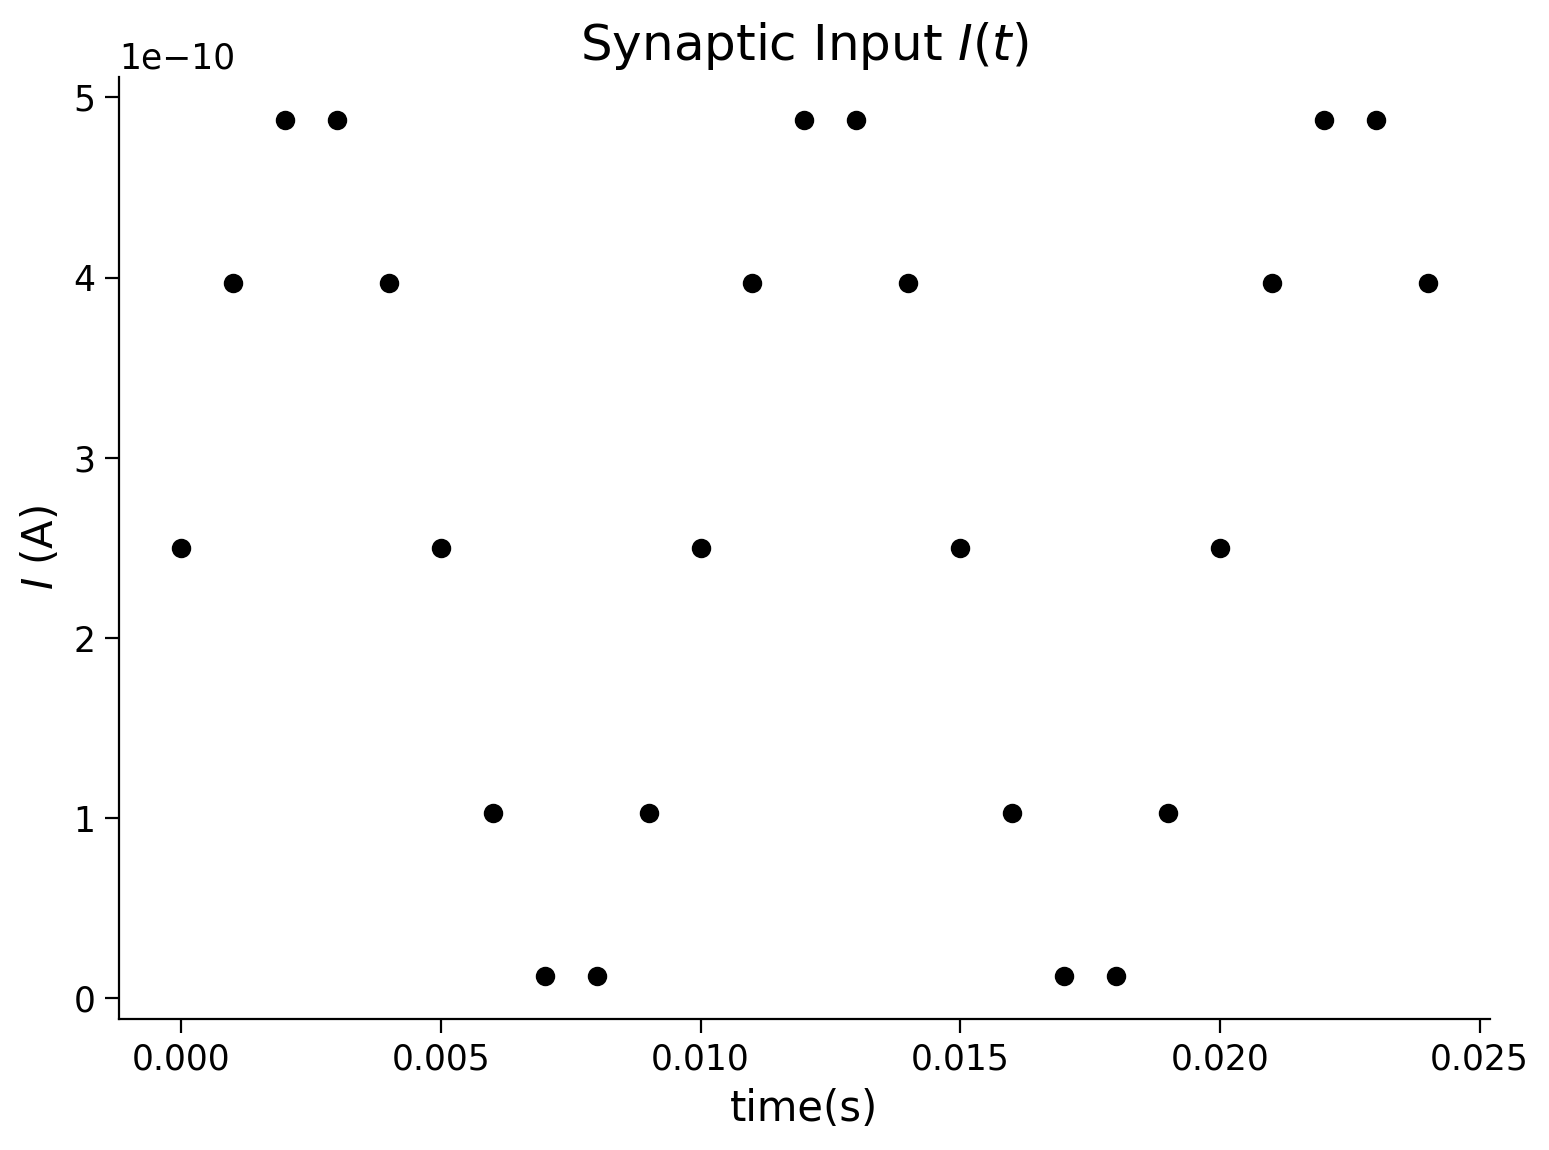

In [ ]:
#################################################
## TODO for students: fill out the figure initialization and plotting code below ##
# Fill out code and comment or remove the next line

# Initialize step_end
step_end = 25

# Initialize the figure
plt.figure()
plt.title('Synaptic Input $I(t)$')
plt.xlabel('time(s)')
plt.ylabel('$I$ (A)')

# Loop for step_end steps
for step in range(step_end):

  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

  # Plot i (use 'ko' to get small black dots (short for color='k' and marker = 'o'))
  plt.plot(t, i, 'ko')

# Display the plot
plt.show()

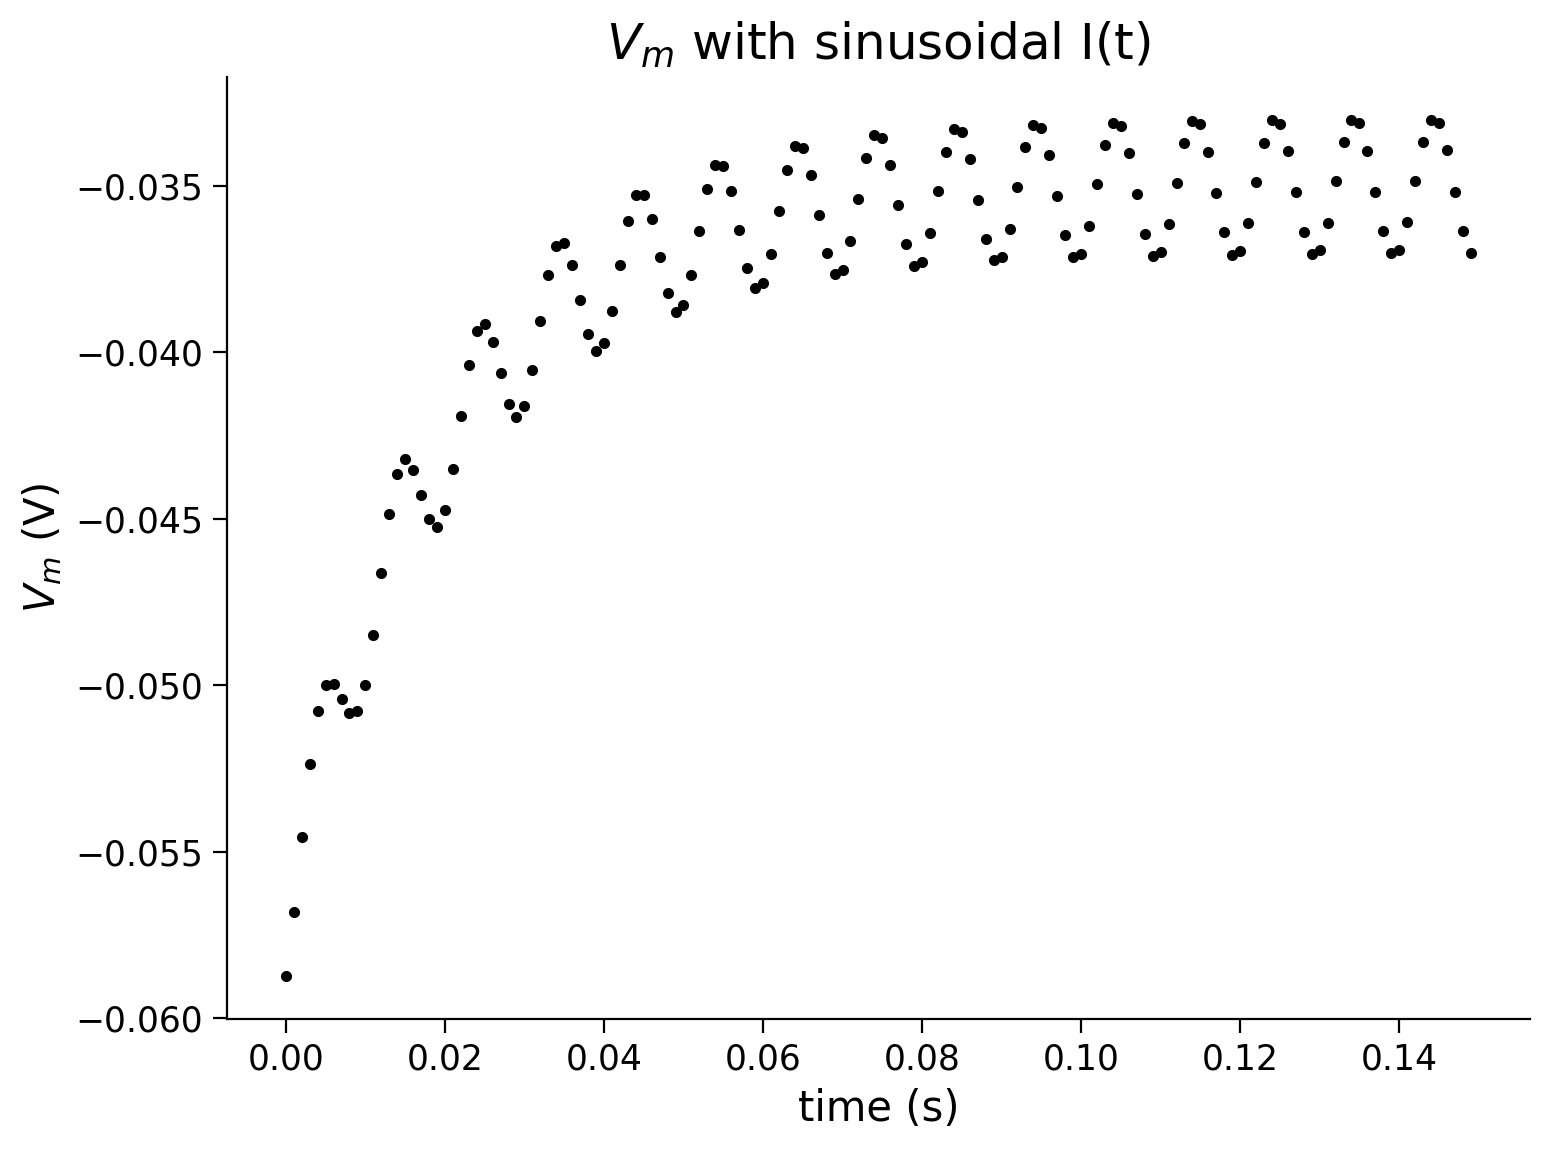

In [ ]:
# Initialize step_end
step_end = int(t_max / dt)

# Initialize v0
v = el

# Initialize the figure
plt.figure()
plt.title('$V_m$ with sinusoidal I(t)')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)');

# Loop for step_end steps
for step in range(step_end):

  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

  # Compute v
  v = v + dt/tau * (el - v + r*i)

  # Plot v (using 'k.' to get even smaller markers)
  plt.plot(t, v, 'k.')

# Display plot
plt.show()

###**Coding Exercise 7: Adding randomness**

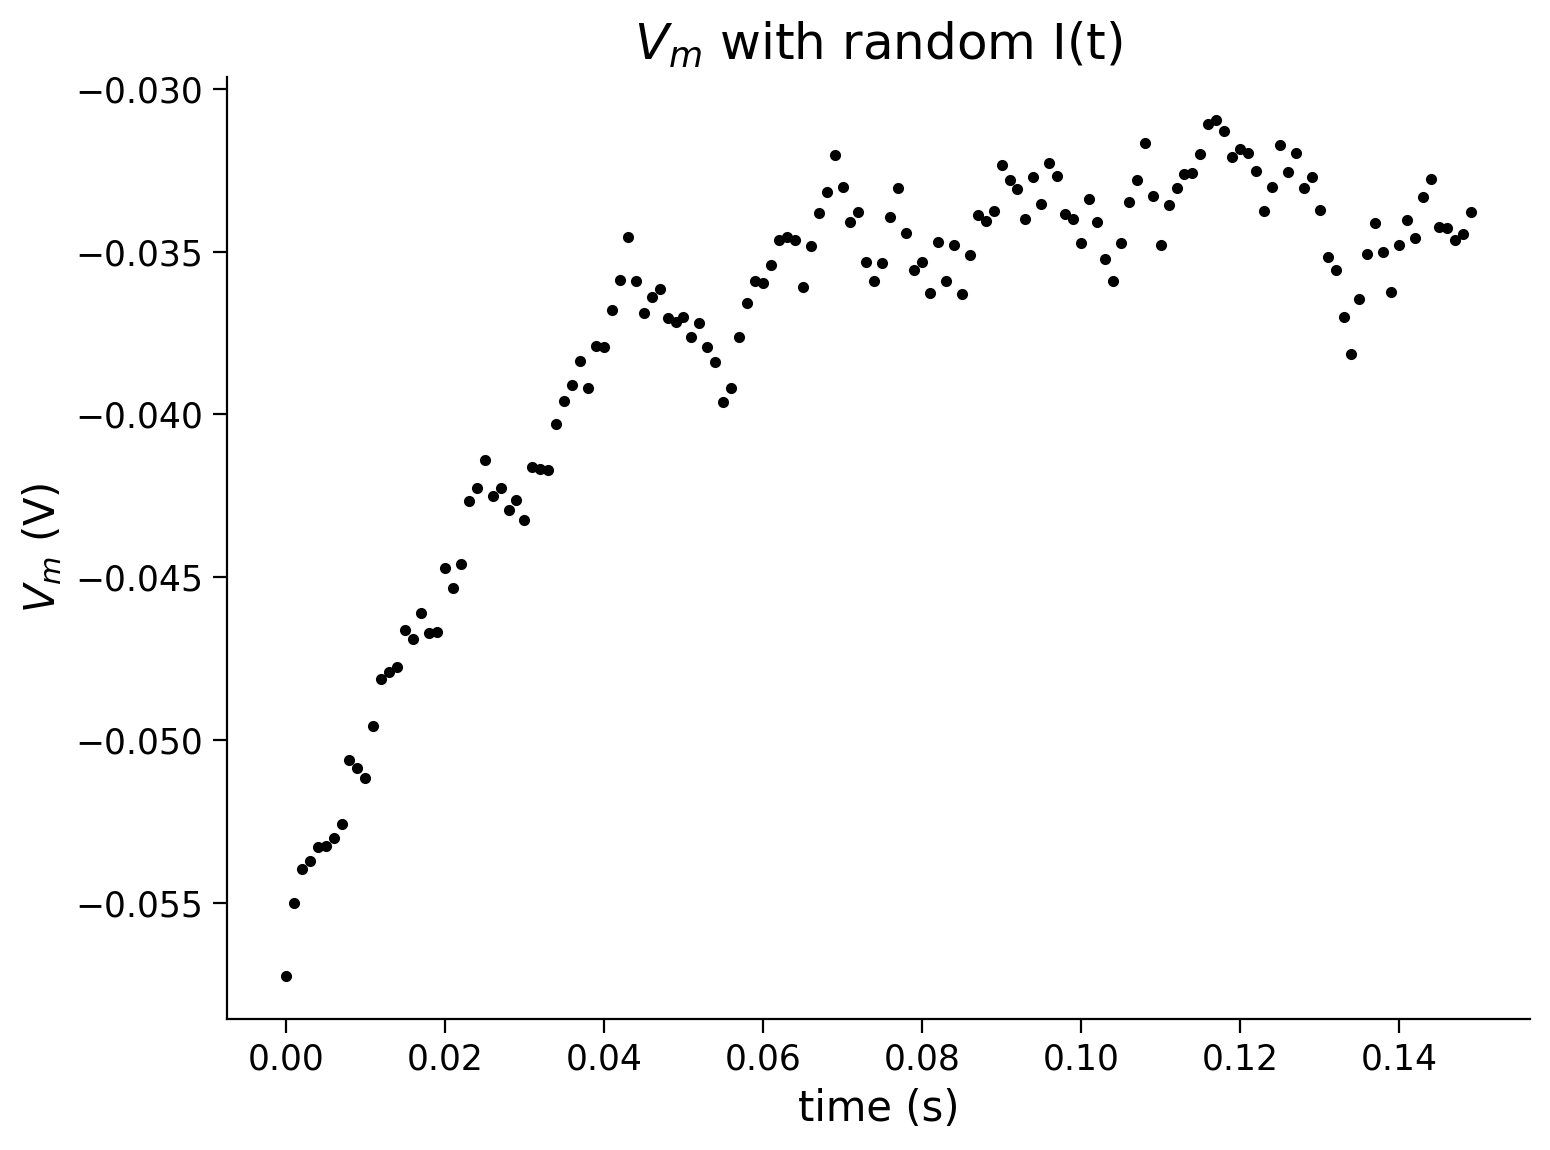

In [14]:
np.random.seed(2020)

# Initialize step_end and v
step_end = int(t_max / dt)
v = el

# Initialize the figure
plt.figure()
plt.title('$V_m$ with random I(t)')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

# loop for step_end steps
for step in range(step_end):

  # Compute value of t
  t = step * dt

  # Get random number in correct range of -1 to 1 (will need to adjust output of np.random.random)
  random_num = np.random.random() * 2 - 1

  # Compute value of i at this time step
  i = i_mean * (1 + 0.1 * np.sqrt(t_max / dt) * random_num)

  # Compute v
  v = v + dt/tau * (el - v + r*i)

  # Plot v (using 'k.' to get even smaller markers)
  plt.plot(t, v, 'k.')


# Display plot
plt.show()